In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("/content/drive/MyDrive/datasets/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Rows and columns:" ,df.shape)

Rows and columns: (891, 12)


In [6]:
print("Column Names:" ,df.columns)

Column Names: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
num = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:")
print(num)

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [9]:
categorical = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(categorical)

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


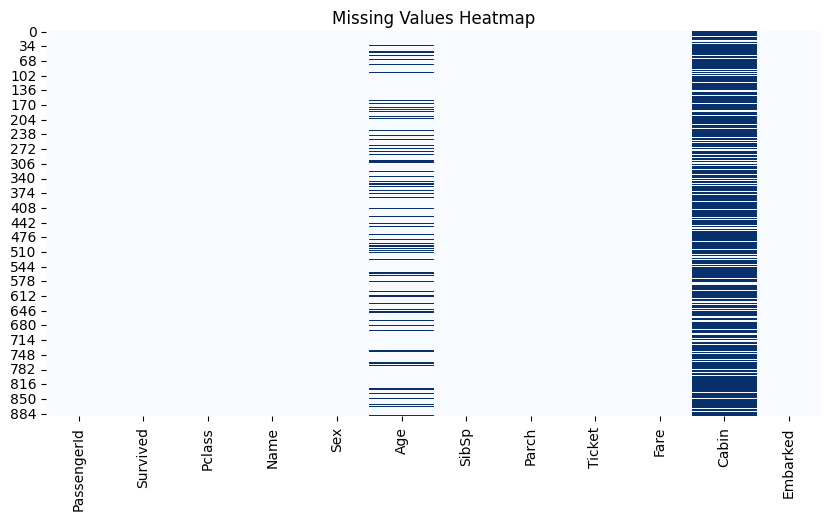

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Values Heatmap")
plt.show()

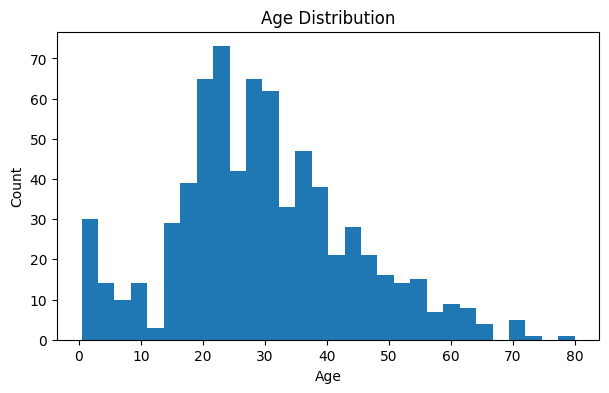

In [11]:
plt.figure(figsize=(7,4))
plt.hist(df["Age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

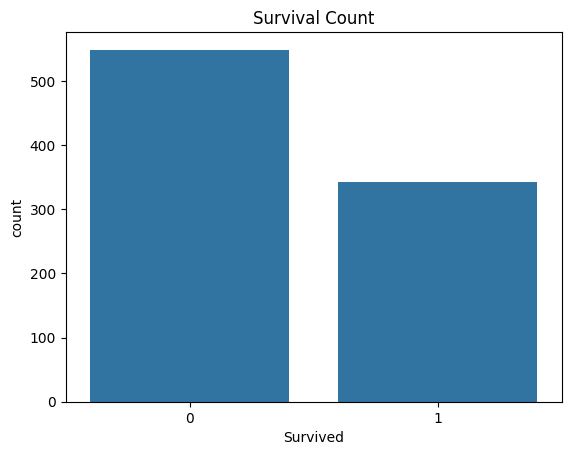

In [12]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

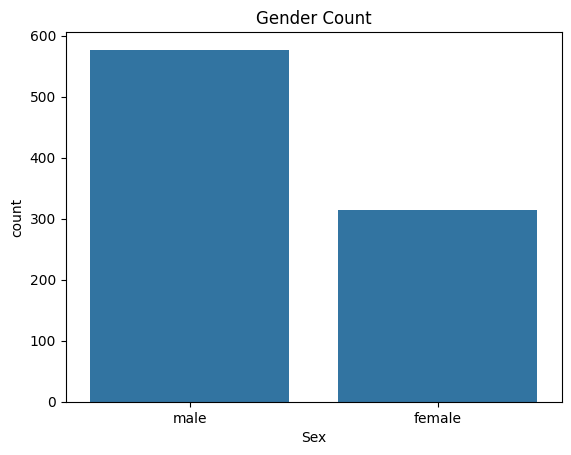

In [13]:
sns.countplot(x="Sex", data=df)
plt.title("Gender Count")
plt.show()

# Titanic Dataset Summary

The Titanic dataset contains information about 891 passengers with 12 features. Some columns such as Age, Cabin, and Embarked contain missing values. The dataset consists of both numerical and categorical variables including age, fare, gender, and passenger class. Initial exploration shows that the Cabin column has the highest number of missing values. This exploratory analysis helps understand the dataset before applying machine learning models.

In [27]:
print(df.isnull().sum())

# median imputation on age column
df["Age"]= df["Age"].fillna(df["Age"].median())

# mode imputation on embarked column
df["Embarked"]= df["Embarked"].fillna(df["Embarked"].mode()[0])

# droping cabin column as it contains most missing values
df = df.drop(columns=["Cabin"])

print("\nAfter imputation and dropping cabin column:")
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After imputation and dropping cabin column:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Handling Missing Values**

The **Age** column contained missing values, so I replaced them with the median because age is numerical and the median is not affected by outliers.
The **Embarked** column had only a few missing values, so I filled them with the most frequent value (mode).
The **Cabin** column had too many missing values, so it was removed because it would not provide reliable information for analysis.

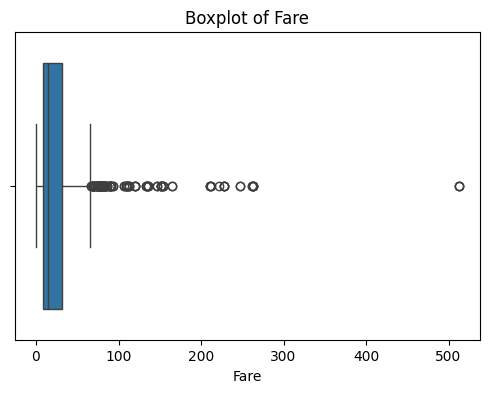

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Boxplot of Fare")
plt.show()

**Observation**

The Fare column contains several outliers. This is expected because a small number of passengers paid much higher ticket prices than the majority.

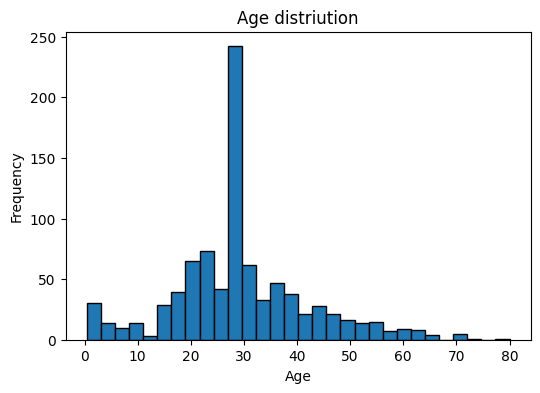

In [30]:
plt.figure(figsize=(6,4))
plt.hist(df["Age"],bins=30, edgecolor="black")
plt.title("Age distriution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Observation**

Most passengers were between 20 and 40 years old.

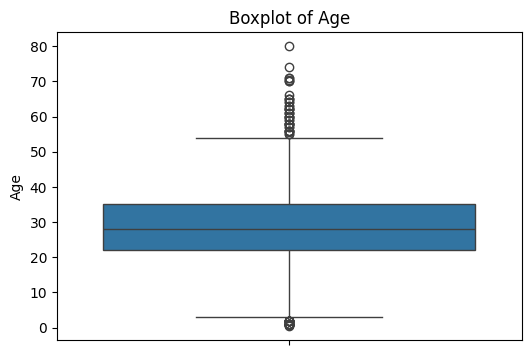

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Age"])
plt.title("Boxplot of Age")
plt.show()


**Observation**

There are a few age outliers, especially older passengers.

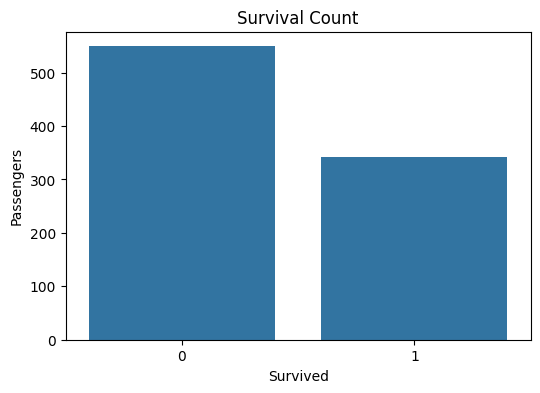

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.ylabel("Passengers")
plt.show()


**Observation**

The plot shows a clear class imbalance in the target variable (Survived), where overall deaths significantly exceed overall survivals. Passengers in first class had a higher survival rate than passengers in third class.

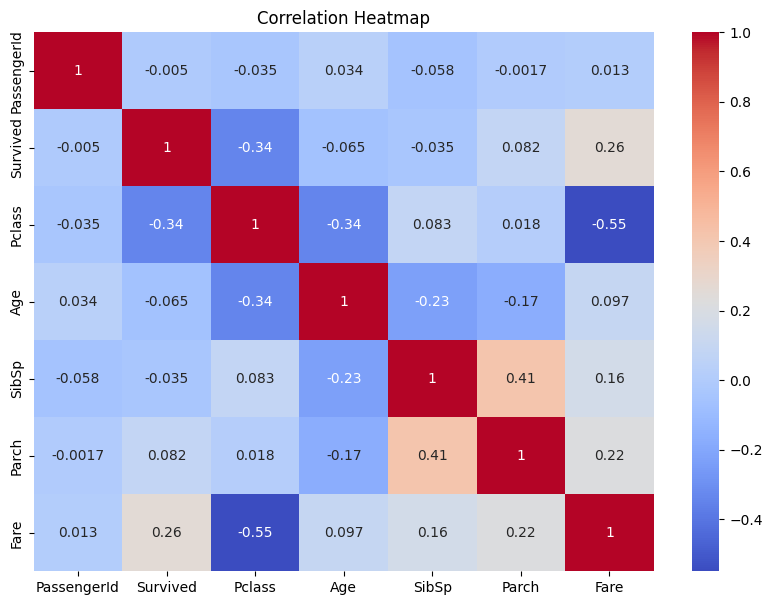

In [36]:
numeric_df=df.select_dtypes(include=["number"])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(),annot= True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation**

The heatmap highlights a strong inverse relationship between Fare and Pclass (-0.55), along with key survival trends where higher passenger class (-0.34) and higher fares (0.26) positively correlate with survival (Survived). Features like PassengerId show negligible correlation across all variables.







**Which feature most affects survival, and why?**

I believe Passenger Class (Pclass) has the greatest effect on survival. First-class passengers had better access to lifeboats and were located closer to the upper decks, making evacuation easier. The visualizations show that first-class passengers survived more often than third-class passengers.